# MVP — Análise de Dados e Boas Práticas  
## Projeto: recomendação de anúncios com foco em canal preferido

**Nome:** Maria Izabel da Silva Aragão

**Matricula:** 4052025002410

**Dataset:**[FMCG Equilibrium - Customer Pulse 2026](https://www.kaggle.com/datasets/amritanshukush/fmcg-equilibrium-customer-pulse-2026)

Data: preencher

## 1. Contexto do problema

Neste projeto, o objetivo é analisar uma base de dados de consumidores e preparar os dados para uma futura etapa de modelagem voltada à **recomendação de anúncios**.

A lógica de negócio adotada aqui é a seguinte: se eu consigo entender **qual canal de comunicação tende a ser preferido por cada perfil de usuário**, então consigo direcionar melhor a entrega de anúncios, campanhas e mensagens promocionais.

Em termos analíticos, isso transforma o problema em uma tarefa de **classificação multiclasse**, na qual a variável alvo será:

- **`Preferred_Channel`**

Ou seja, queremos prever o canal preferido do consumidor com base em suas características demográficas, econômicas e comportamentais.

---

## 2. Hipóteses iniciais

Antes de explorar a base, as hipóteses iniciais são:

1. idade, renda e gasto mensal podem influenciar o canal preferido;
2. variáveis ligadas a preço e marca também podem ter relação com o canal;
3. a influência principal sobre o consumidor pode ser um atributo importante para entender sua resposta a anúncios;
4. clientes com perfis diferentes de fidelidade podem responder melhor a canais distintos.

---

## 3. Decisões metodológicas adotadas

Para deixar o projeto coerente com o objetivo de ads recommendation, as decisões deste notebook são:

- a variável alvo será **`Preferred_Channel`**;
- a coluna **`User_ID`** será removida da modelagem, porque funciona apenas como identificador;
- o notebook será estruturado para rodar no **Google Colab**;
- o dataset será lido a partir da **URL raw do GitHub**;
- a análise irá até a etapa de **pré-processamento**, conforme pedido no MVP;
- serão geradas diferentes versões do dataset para uso futuro em modelagem.

---

## 4. O que este notebook entrega

Ao final, este notebook irá:

- carregar a base a partir do GitHub;
- inspecionar a estrutura dos dados;
- documentar os atributos;
- fazer análise exploratória com gráficos e estatísticas;
- verificar valores faltantes e duplicatas;
- tratar os dados;
- criar bases derivadas:
  - base limpa,
  - base com target separado,
  - base com one-hot encoding,
  - base padronizada,
  - base normalizada,
  - base com discretização de variáveis numéricas selecionadas.

O notebook foi escrito para servir também como **material didático**, isto é, com explicações suficientes para que outra pessoa consiga entender e replicar o projeto.

In [ ]:
# ============================================================
# 0) Instalação opcional
# Nesta versão, a leitura será feita direto do GitHub.
# Então não preciso mais do gdown.
# ============================================================

# Nenhuma instalação adicional é necessária para a leitura do dataset.


In [ ]:
# ============================================================
# 1) Imports e configurações
# Aqui eu concentro as bibliotecas usadas no projeto.
# A ideia é deixar o resto do notebook mais limpo.
# ============================================================

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

PROJECT_DIR = Path("/content/mvp_ads_recommendation_v7")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

print("Pasta do projeto:", PROJECT_DIR)


Pasta do projeto: /content/mvp_ads_recommendation_v7


## Explicação dos pacotes utilizados

Nesta etapa é importante entender o papel de cada biblioteca:

- **pandas**: principal ferramenta para manipular dados em formato de tabela (DataFrame).  
  Permite filtrar, transformar, agrupar e analisar os dados.

- **numpy**: usado para operações numéricas eficientes, principalmente em arrays e cálculos matemáticos.

- **matplotlib**: biblioteca base para criação de gráficos.

- **seaborn**: extensão do matplotlib que facilita a criação de gráficos mais bonitos e informativos.

- **scikit-learn (sklearn)**: biblioteca de machine learning que usamos para:
  - dividir treino/teste,
  - treinar modelos,
  - calcular métricas,
  - fazer transformações nos dados.

Essas bibliotecas são padrão em projetos de ciência de dados e aparecem em praticamente todo fluxo de análise.

## 5. Leitura do dataset

O arquivo será lido a partir do **GitHub**, conforme exigido no MVP.  
Isso é importante porque garante reprodutibilidade: qualquer pessoa com o link do repositório consegue rodar o notebook no Colab.

Nesta etapa, vou:
1. definir a URL raw do dataset no GitHub;
2. carregar a base com `pandas.read_csv`;
3. confirmar a estrutura inicial do arquivo.


In [ ]:
# ============================================================
# 2) URL do dataset no GitHub
# Esse é o link raw, isto é, o link direto para o arquivo CSV.
# É ele que o pandas consegue ler.
# ============================================================

DATA_URL = "https://raw.githubusercontent.com/ultimatejuliano/AdRecommendation_Project/main/fmcg_data.csv"

print("URL do dataset:")
print(DATA_URL)


URL do dataset:
https://raw.githubusercontent.com//AdRecommendation_Project/main/fmcg_data.csv


In [ ]:
# ============================================================
# 3) Ler o dataset
# Como o arquivo já está em CSV e o link é raw, a leitura é direta.
# ============================================================

df_raw = pd.read_csv(DATA_URL)

print("Dataset carregado com sucesso.")
print("Shape inicial:", df_raw.shape)
display(df_raw.head())


Dataset carregado com sucesso.
Shape inicial: (100000, 11)


,User_ID,Age,Household_Size,Monthly_Income,Monthly_Spend,Preferred_Channel,Brand_Importance_Rating,Price_Importance_Rating,Price_Hike_Reaction,Primary_Influence,Loyalty_Score
0,1,56,3,52500,9497,Supermarkets,3,2,Continue buying the same brand,Social Media Ads,0.58
1,2,69,4,50500,7751,Local Kirana/Mom-and-pop Stores,2,4,Switch to a cheaper brand,Social Media Ads,0.40
2,3,46,2,30500,3602,E-commerce/Apps,3,4,Switch to a cheaper brand,TV Commercials,0.45
3,4,32,2,51500,7967,Supermarkets,2,4,Switch to a cheaper brand,In-store Displays,0.35
4,5,60,3,24000,4533,E-commerce/Apps,1,5,Switch to a cheaper brand,Doctor Recommendation,0.13


In [ ]:
# ============================================================
# 4) Conferência rápida da leitura
# Se esta célula rodar bem, o acesso ao GitHub está correto.
# ============================================================

print("Número de linhas:", df_raw.shape[0])
print("Número de colunas:", df_raw.shape[1])
print("\nTipos iniciais:")
display(df_raw.dtypes.to_frame("dtype"))


Número de linhas: 100000
Número de colunas: 11

Tipos iniciais:


,dtype
User_ID,int64
Age,int64
Household_Size,int64
Monthly_Income,int64
Monthly_Spend,int64
Preferred_Channel,object
Brand_Importance_Rating,int64
Price_Importance_Rating,int64
Price_Hike_Reaction,object
Primary_Influence,object


## 6. Entendimento inicial da base

Agora que a base foi carregada, o objetivo é entender sua estrutura real.

Pelo conteúdo do dataset, este projeto não é sobre clique observado diretamente.  
Em vez disso, a base descreve perfis de consumidores e suas preferências, o que permite formular um problema muito coerente de ads recommendation:

> **prever o canal preferido do usuário**, isto é, a coluna `Preferred_Channel`.

Essa escolha faz sentido porque, em marketing, o canal de comunicação é uma decisão central.

In [ ]:
# ============================================================
# 5) Primeira inspeção
# Aqui olho shape, nomes das colunas e primeiras linhas.
# ============================================================

print("Número de linhas:", df_raw.shape[0])
print("Número de colunas:", df_raw.shape[1])

print("\nColunas originais:")
print(list(df_raw.columns))

display(df_raw.head())

Número de linhas: 100000
Número de colunas: 11

Colunas originais:
['User_ID', 'Age', 'Household_Size', 'Monthly_Income', 'Monthly_Spend', 'Preferred_Channel', 'Brand_Importance_Rating', 'Price_Importance_Rating', 'Price_Hike_Reaction', 'Primary_Influence', 'Loyalty_Score']


,User_ID,Age,Household_Size,Monthly_Income,Monthly_Spend,Preferred_Channel,Brand_Importance_Rating,Price_Importance_Rating,Price_Hike_Reaction,Primary_Influence,Loyalty_Score
0,1,56,3,52500,9497,Supermarkets,3,2,Continue buying the same brand,Social Media Ads,0.58
1,2,69,4,50500,7751,Local Kirana/Mom-and-pop Stores,2,4,Switch to a cheaper brand,Social Media Ads,0.40
2,3,46,2,30500,3602,E-commerce/Apps,3,4,Switch to a cheaper brand,TV Commercials,0.45
3,4,32,2,51500,7967,Supermarkets,2,4,Switch to a cheaper brand,In-store Displays,0.35
4,5,60,3,24000,4533,E-commerce/Apps,1,5,Switch to a cheaper brand,Doctor Recommendation,0.13


In [ ]:
# ============================================================
# 6) Renomear colunas de forma simples e explícita
# Como eu já conheço a base, prefiro fazer isso manualmente.
# Fica mais claro, mais fácil de ensinar e mais fácil de manter.
# ============================================================

df = df_raw.copy()

df.columns = [
    "user_id",               # identificador do usuário
    "age",                   # idade
    "household_size",        # tamanho do domicílio
    "monthly_income",        # renda mensal
    "monthly_spend",         # gasto mensal
    "preferred_channel",     # canal preferido (variável alvo)
    "brand_importance",      # importância da marca
    "price_importance",      # importância do preço
    "price_hike_reaction",   # reação a aumento de preço
    "primary_influence",     # principal influência de compra
    "loyalty_score"          # score de fidelidade
]

print("Colunas após renomeação:")
print(df.columns.tolist())

display(df.head())


Colunas após renomeação:
['user_id', 'age', 'household_size', 'monthly_income', 'monthly_spend', 'preferred_channel', 'brand_importance', 'price_importance', 'price_hike_reaction', 'primary_influence', 'loyalty_score']


,user_id,age,household_size,monthly_income,monthly_spend,preferred_channel,brand_importance,price_importance,price_hike_reaction,primary_influence,loyalty_score
0,1,56,3,52500,9497,Supermarkets,3,2,Continue buying the same brand,Social Media Ads,0.58
1,2,69,4,50500,7751,Local Kirana/Mom-and-pop Stores,2,4,Switch to a cheaper brand,Social Media Ads,0.40
2,3,46,2,30500,3602,E-commerce/Apps,3,4,Switch to a cheaper brand,TV Commercials,0.45
3,4,32,2,51500,7967,Supermarkets,2,4,Switch to a cheaper brand,In-store Displays,0.35
4,5,60,3,24000,4533,E-commerce/Apps,1,5,Switch to a cheaper brand,Doctor Recommendation,0.13


In [ ]:
# ============================================================
# 9) Definir o alvo e remover o identificador
# Preferred Channel será a variável que queremos prever.
# User ID sai da modelagem porque só identifica a linha.
# ============================================================

TARGET_COL = "preferred_channel"
ID_COL = "user_id"

if TARGET_COL not in df.columns:
    raise ValueError(f"A coluna alvo esperada '{TARGET_COL}' não foi encontrada.")

if ID_COL in df.columns:
    df = df.drop(columns=[ID_COL])

print("Variável alvo:", TARGET_COL)
print("Shape após remover identificador:", df.shape)
display(df.head())


Variável alvo: preferred_channel
Shape após remover identificador: (100000, 10)


,age,household_size,monthly_income,monthly_spend,preferred_channel,brand_importance,price_importance,price_hike_reaction,primary_influence,loyalty_score
0,56,3,52500,9497,Supermarkets,3,2,Continue buying the same brand,Social Media Ads,0.58
1,69,4,50500,7751,Local Kirana/Mom-and-pop Stores,2,4,Switch to a cheaper brand,Social Media Ads,0.40
2,46,2,30500,3602,E-commerce/Apps,3,4,Switch to a cheaper brand,TV Commercials,0.45
3,32,2,51500,7967,Supermarkets,2,4,Switch to a cheaper brand,In-store Displays,0.35
4,60,3,24000,4533,E-commerce/Apps,1,5,Switch to a cheaper brand,Doctor Recommendation,0.13


## 7. Dicionário dos atributos

Como agora já sabemos a estrutura real da base, podemos documentar os atributos de forma mais concreta.

Os principais atributos são:

- `age`: idade do consumidor;
- `household_size`: tamanho do domicílio;
- `monthly_income`: renda mensal;
- `monthly_spend`: gasto mensal;
- `preferred_channel`: canal preferido do consumidor;
- `brand_importance_rating`: importância atribuída à marca;
- `price_importance_rating`: importância atribuída ao preço;
- `price_hike_reaction`: reação a aumento de preço;
- `primary_influence`: principal influência sobre a decisão;
- `loyalty_score`: escore de fidelidade.

A coluna `user_id` foi removida da análise porque funciona apenas como identificador.

In [ ]:
# ============================================================
# 8) Dicionário operacional dos atributos
# Essa tabela resume o que existe na base depois da renomeação.
# ============================================================

attribute_dictionary = pd.DataFrame({
    "atributo": df.columns,
    "tipo_pandas": df.dtypes.astype(str).values,
    "missing": df.isna().sum().values,
    "n_unicos": df.nunique(dropna=True).values
})

display(attribute_dictionary)


,atributo,tipo_pandas,missing,n_unicos
0,age,int64,0,57
1,household_size,int64,0,6
2,monthly_income,int64,0,392
3,monthly_spend,int64,0,14113
4,preferred_channel,object,0,4
5,brand_importance,int64,0,5
6,price_importance,int64,0,5
7,price_hike_reaction,object,0,3
8,primary_influence,object,0,5
9,loyalty_score,float64,0,101


## 8. Análise exploratória dos dados

Agora começa a análise de dados propriamente dita.

Vou seguir uma lógica didática:
1. entender tipos e missing;
2. verificar duplicatas;
3. resumir variáveis numéricas;
4. resumir variáveis categóricas;
5. analisar a distribuição do alvo;
6. cruzar o alvo com atributos importantes.

In [ ]:
# ============================================================
# 9) Informações gerais da base
# Aqui vejo tipos, contagem de não nulos e memória.
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   age                  100000 non-null  int64  
 1   household_size       100000 non-null  int64  
 2   monthly_income       100000 non-null  int64  
 3   monthly_spend        100000 non-null  int64  
 4   preferred_channel    100000 non-null  object 
 5   brand_importance     100000 non-null  int64  
 6   price_importance     100000 non-null  int64  
 7   price_hike_reaction  100000 non-null  object 
 8   primary_influence    100000 non-null  object 
 9   loyalty_score        100000 non-null  float64
dtypes: float64(1), int64(6), object(3)
memory usage: 7.6+ MB


In [ ]:
# ============================================================
# 10) Valores faltantes
# Primeiro quantifico missing absoluto e percentual.
# ============================================================

missing_abs = df.isna().sum().sort_values(ascending=False)
missing_pct = (100 * df.isna().mean()).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_abs": missing_abs,
    "missing_pct": missing_pct.round(2)
})

display(missing_summary)

,missing_abs,missing_pct
age,0,0.0
household_size,0,0.0
monthly_income,0,0.0
monthly_spend,0,0.0
preferred_channel,0,0.0
brand_importance,0,0.0
price_importance,0,0.0
price_hike_reaction,0,0.0
primary_influence,0,0.0
loyalty_score,0,0.0


### Comentário sobre valores faltantes

Nesta base, uma das primeiras coisas que chama atenção é que o problema de missing parece ser pequeno ou até inexistente em várias colunas.

Isso é importante por dois motivos:
- mostra que a qualidade inicial da base é boa;
- evita que a gente invente imputações desnecessárias.

Mesmo assim, a checagem precisa ser feita formalmente, porque isso faz parte do diagnóstico correto da base.

In [ ]:
# ============================================================
# 11) Duplicatas
# Duplicata exata pode distorcer frequências e estatísticas.
# ============================================================

n_duplicates = df.duplicated().sum()
print("Número de linhas duplicadas:", n_duplicates)

Número de linhas duplicadas: 1


In [ ]:
# ============================================================
# 12) Separar grupos de variáveis por tipo
# Isso organiza o restante da análise e do pré-processamento.
# ============================================================

numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = [col for col in df.columns if col not in numeric_cols]

print("Numéricas:", numeric_cols)
print("Categóricas:", categorical_cols)

Numéricas: ['age', 'household_size', 'monthly_income', 'monthly_spend', 'brand_importance', 'price_importance', 'loyalty_score']
Categóricas: ['preferred_channel', 'price_hike_reaction', 'primary_influence']


In [ ]:
# ============================================================
# 13) Resumo estatístico dos atributos numéricos
# Incluo min, max, mediana, moda, média, desvio e missing.
# ============================================================

numeric_summary_rows = []

for col in numeric_cols:
    s = df[col]
    numeric_summary_rows.append({
        "atributo": col,
        "min": s.min(),
        "max": s.max(),
        "mediana": s.median(),
        "moda": s.mode(dropna=True).iloc[0] if not s.mode(dropna=True).empty else np.nan,
        "media": s.mean(),
        "desvio_padrao": s.std(),
        "missing": s.isna().sum()
    })

numeric_summary = pd.DataFrame(numeric_summary_rows)
display(numeric_summary)

,atributo,min,max,mediana,moda,media,desvio_padrao,missing
0,age,18.0,74.0,46.00,71.00,46.03367,16.433943,0
1,household_size,1.0,6.0,3.00,3.00,3.09388,1.300263,0
2,monthly_income,3500.0,355000.0,36000.00,28500.00,40939.08500,21927.785459,0
3,monthly_spend,2000.0,40000.0,5733.00,2000.00,6397.94470,3396.859502,0
4,brand_importance,1.0,5.0,2.00,2.00,2.52730,1.089223,0
5,price_importance,1.0,5.0,4.00,5.00,3.73353,1.151433,0
6,loyalty_score,0.0,1.0,0.38,0.35,0.40540,0.225252,0


### Comentário sobre as variáveis numéricas

Nesta base, as variáveis numéricas têm interpretações bem claras:
- perfil demográfico (`age`, `household_size`);
- capacidade econômica (`monthly_income`);
- comportamento de consumo (`monthly_spend`);
- sensibilidade a marca e preço;
- fidelidade (`loyalty_score`).

Essas variáveis são especialmente importantes porque podem ajudar a explicar por que diferentes perfis preferem canais diferentes.

In [ ]:
# ============================================================
# 14) Resumo das variáveis categóricas
# Aqui olho cardinalidade e categorias mais frequentes.
# ============================================================

categorical_summary_rows = []

for col in categorical_cols:
    s = df[col]
    top_values = s.value_counts(dropna=False).head(10).to_dict()
    categorical_summary_rows.append({
        "atributo": col,
        "n_unicos": s.nunique(dropna=True),
        "missing": s.isna().sum(),
        "top_valores": top_values
    })

categorical_summary = pd.DataFrame(categorical_summary_rows)
display(categorical_summary)

,atributo,n_unicos,missing,top_valores
0,preferred_channel,4,0,"{'Supermarkets': 40013, 'E-commerce/Apps': 300..."
1,price_hike_reaction,3,0,"{'Switch to a cheaper brand': 62651, 'Continue..."
2,primary_influence,5,0,"{'Social Media Ads': 20070, 'Word of Mouth': 2..."


### Comentário sobre as variáveis categóricas

As variáveis categóricas desta base são poucas, mas muito relevantes:
- `preferred_channel` é o alvo;
- `price_hike_reaction` ajuda a descrever comportamento frente a preço;
- `primary_influence` ajuda a capturar o principal fator de influência sobre o consumidor.

Em um projeto de ads recommendation, isso é ótimo, porque essas colunas têm interpretação direta de marketing.

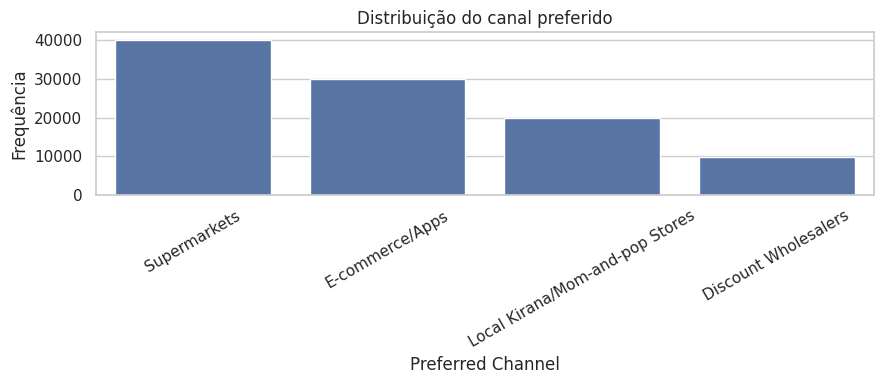

,frequencia,percentual
preferred_channel,,
Supermarkets,40013,40.01
E-commerce/Apps,30028,30.03
Local Kirana/Mom-and-pop Stores,20021,20.02
Discount Wholesalers,9938,9.94


In [ ]:
# ============================================================
# 15) Distribuição da variável alvo
# Como o problema é de classificação, isso é obrigatório.
# ============================================================

plt.figure(figsize=(9, 4))
sns.countplot(data=df, x=TARGET_COL, order=df[TARGET_COL].value_counts().index)
plt.title("Distribuição do canal preferido")
plt.xlabel("Preferred Channel")
plt.ylabel("Frequência")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

target_dist = df[TARGET_COL].value_counts(dropna=False).to_frame("frequencia")
target_dist["percentual"] = (100 * target_dist["frequencia"] / len(df)).round(2)
display(target_dist)

### Comentário sobre a variável alvo

Este gráfico é importante para verificar se as classes estão equilibradas.  
Se alguns canais aparecerem muito mais que outros, isso pode afetar uma futura modelagem.

Mesmo que a etapa atual ainda não seja de treinamento, vale registrar esse ponto desde já.

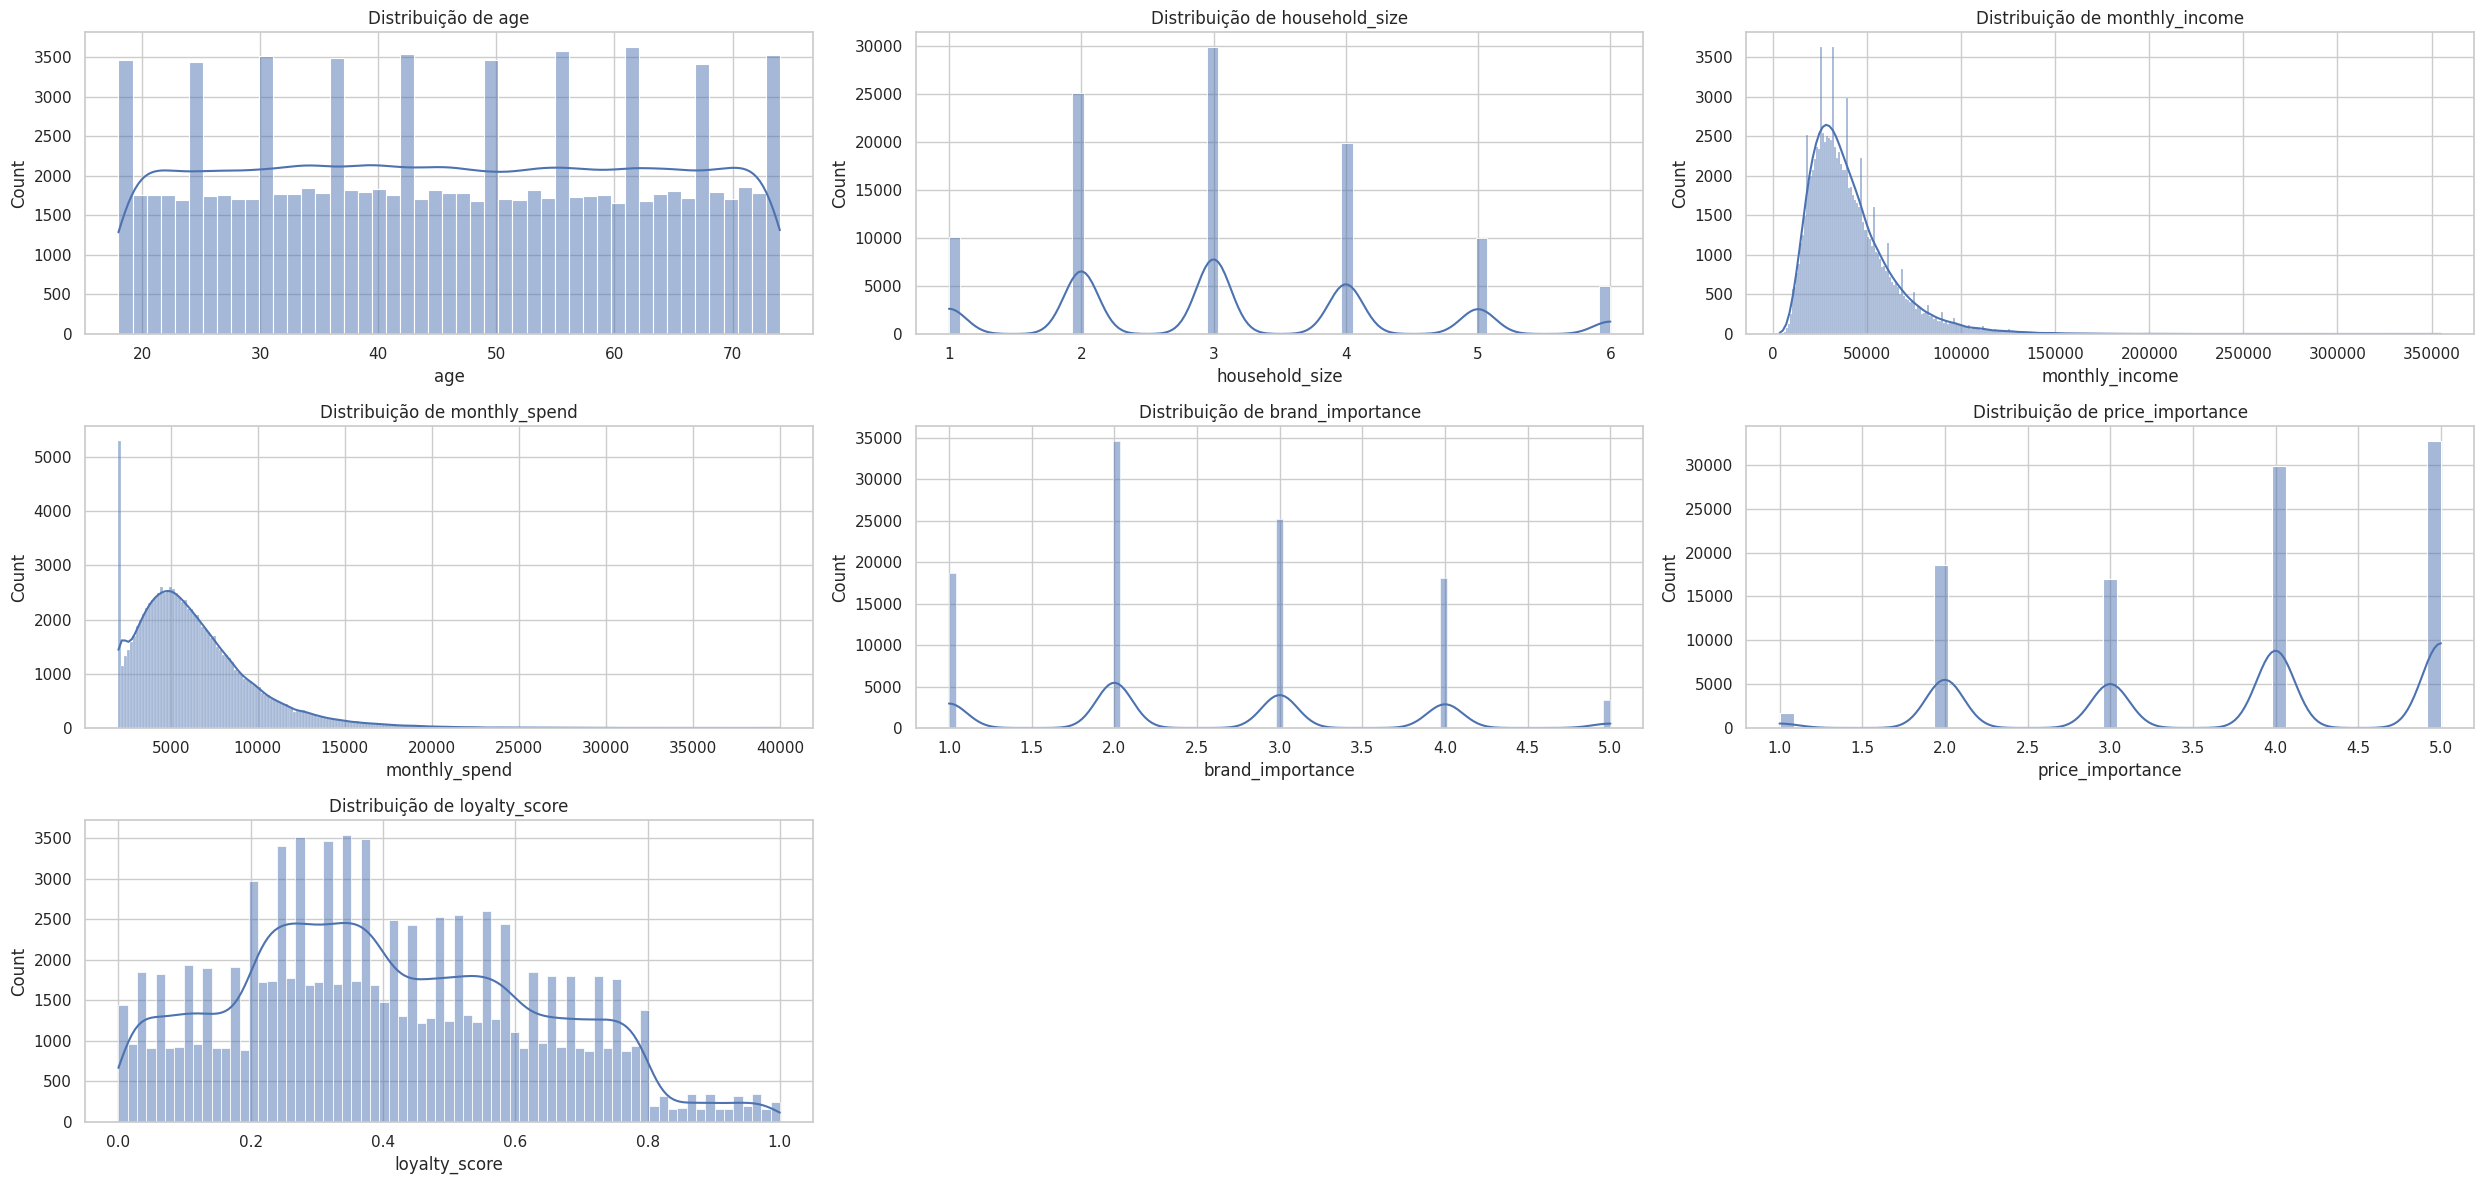

In [ ]:
# ============================================================
# 16) Histogramas das variáveis numéricas
# Aqui consigo ver escala, dispersão e assimetria.
# ============================================================

plot_numeric_cols = numeric_cols

if len(plot_numeric_cols) > 0:
    n_cols = 3
    n_rows = int(np.ceil(len(plot_numeric_cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, plot_numeric_cols):
        sns.histplot(df[col], kde=True, ax=ax)
        ax.set_title(f"Distribuição de {col}")

    for ax in axes[len(plot_numeric_cols):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

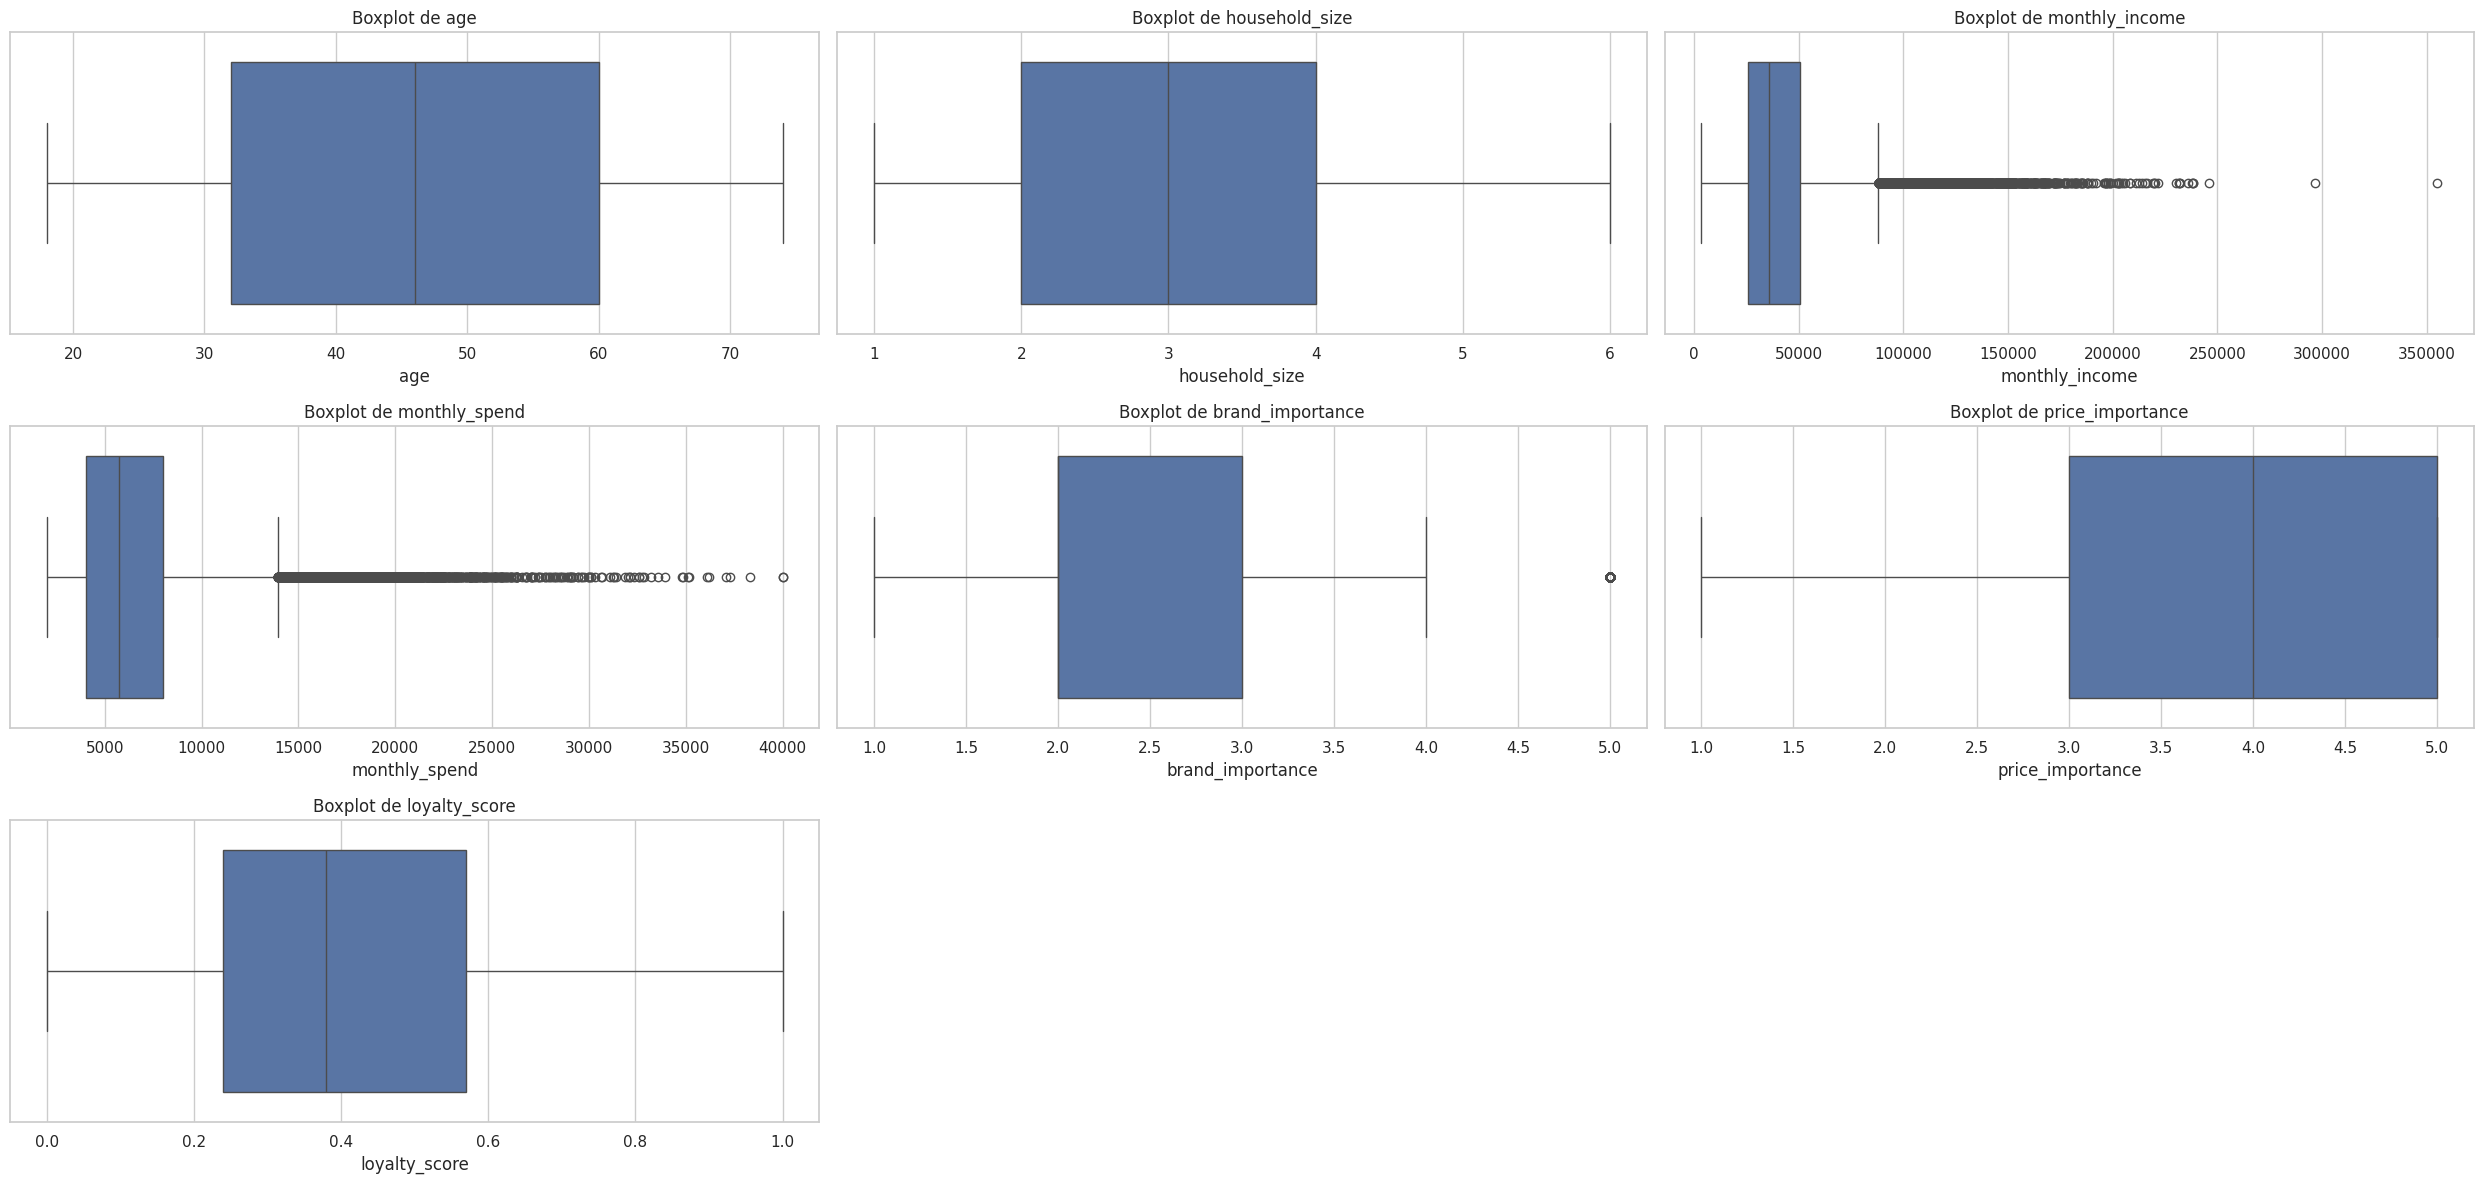

In [ ]:
# ============================================================
# 17) Boxplots das variáveis numéricas
# O foco aqui é enxergar dispersão e possíveis outliers.
# ============================================================

if len(plot_numeric_cols) > 0:
    n_cols = 3
    n_rows = int(np.ceil(len(plot_numeric_cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, plot_numeric_cols):
        sns.boxplot(x=df[col], ax=ax)
        ax.set_title(f"Boxplot de {col}")

    for ax in axes[len(plot_numeric_cols):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

### Comentário sobre as distribuições numéricas

Os gráficos acima ajudam a responder perguntas muito úteis em aula:
- as variáveis estão em escalas muito diferentes?
- existem outliers?
- algumas distribuições parecem mais concentradas?
- a fidelidade e os ratings estão em escalas menores do que renda e gasto?

Essas observações justificam bem a etapa posterior de padronização e normalização.

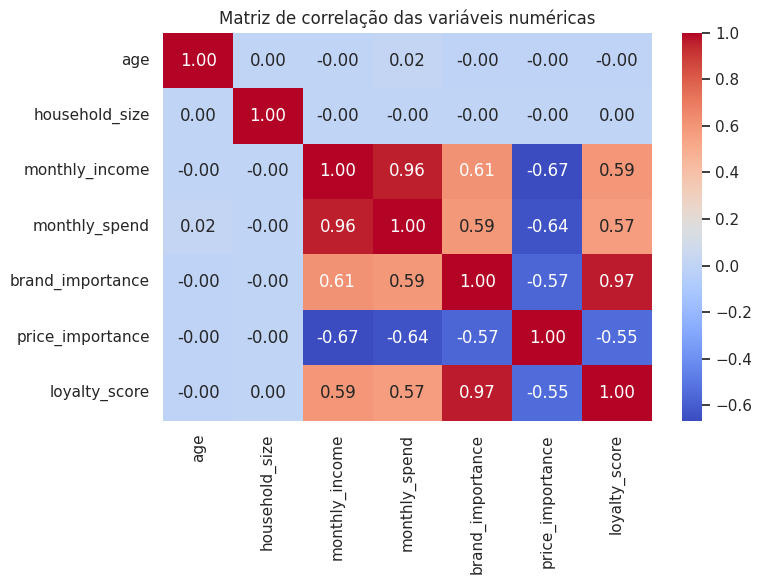

In [ ]:
# ============================================================
# 18) Correlação entre variáveis numéricas
# Isso ajuda a identificar relações lineares iniciais.
# ============================================================

corr = df[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlação das variáveis numéricas")
plt.tight_layout()
plt.show()

### Comentário sobre correlação

A matriz de correlação ajuda a identificar relações lineares entre renda, gasto, fidelidade e demais variáveis numéricas.

Ela não resolve tudo, mas é uma boa triagem inicial para:
- redundância;
- associação linear;
- possíveis padrões econômicos e comportamentais.

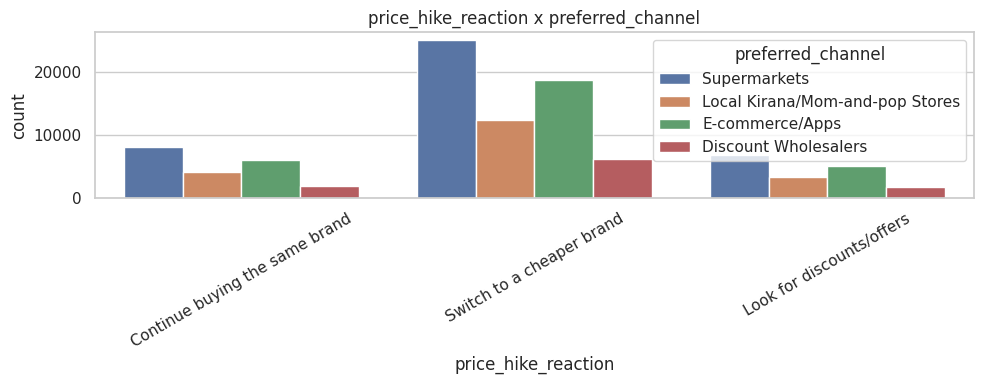

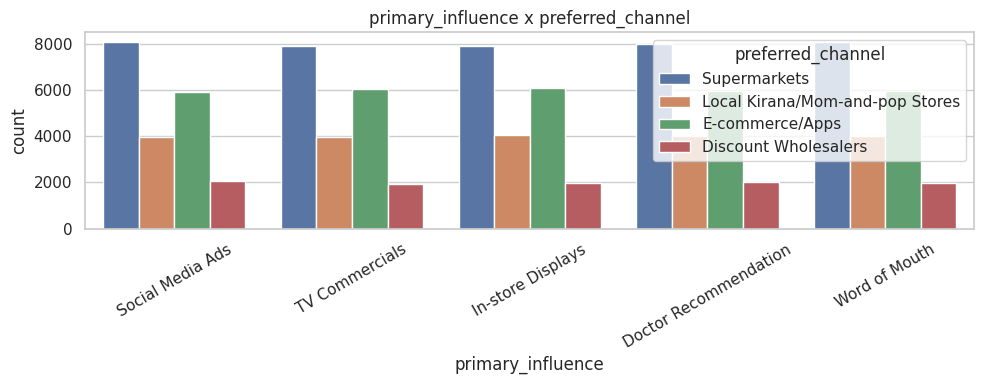

In [ ]:
# ============================================================
# 19) Variáveis categóricas x alvo
# Aqui eu olho categorias importantes em relação ao canal preferido.
# ============================================================

for col in ["price_hike_reaction", "primary_influence"]:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=col, hue=TARGET_COL)
    plt.title(f"{col} x {TARGET_COL}")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

### Comentário sobre os cruzamentos categóricos

Esses gráficos são muito bons para discutir marketing na aula.

Eles ajudam a observar se:
- perfis mais sensíveis a aumento de preço tendem a preferir certos canais;
- diferentes tipos de influência estão associados a canais distintos.

Esse tipo de análise conecta diretamente os dados com decisões de campanha.

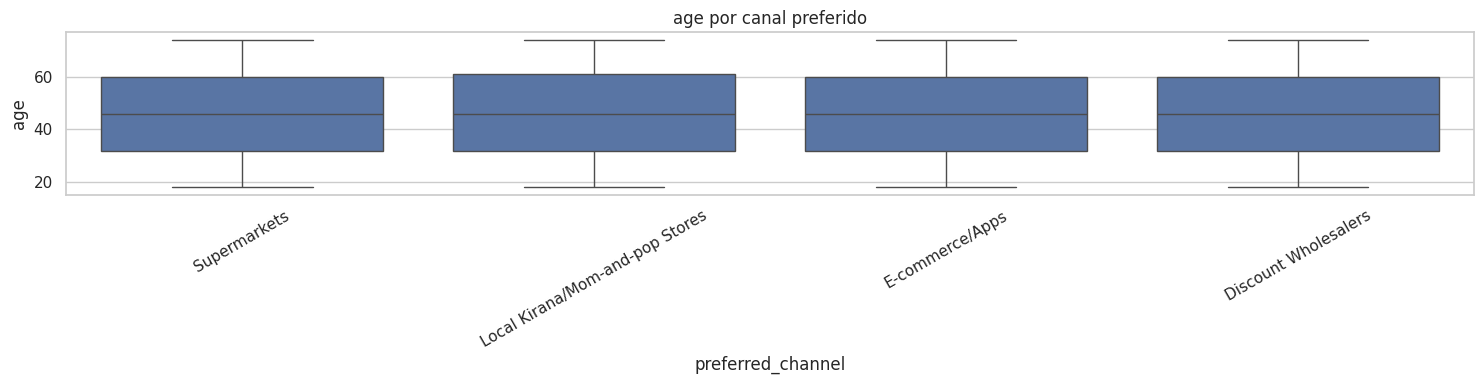

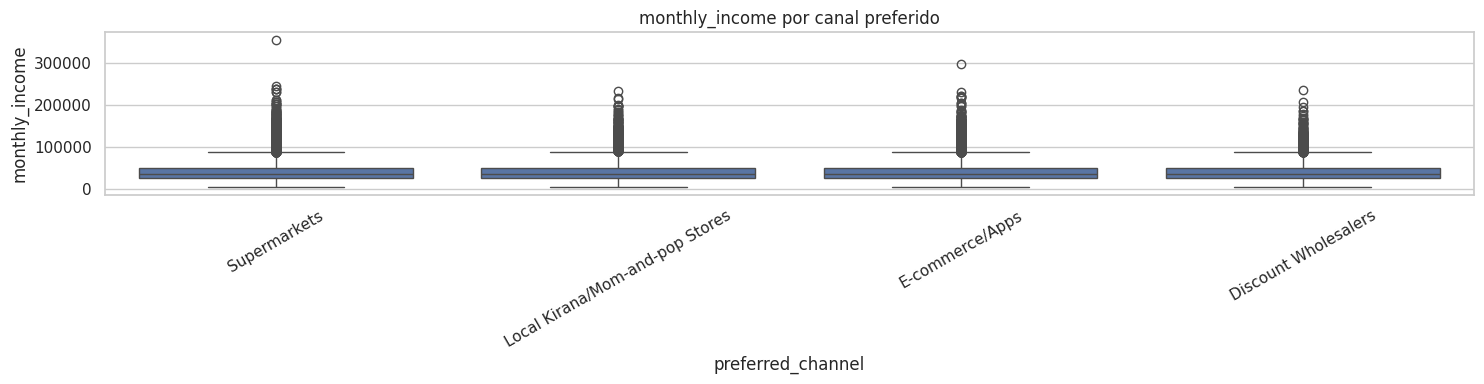

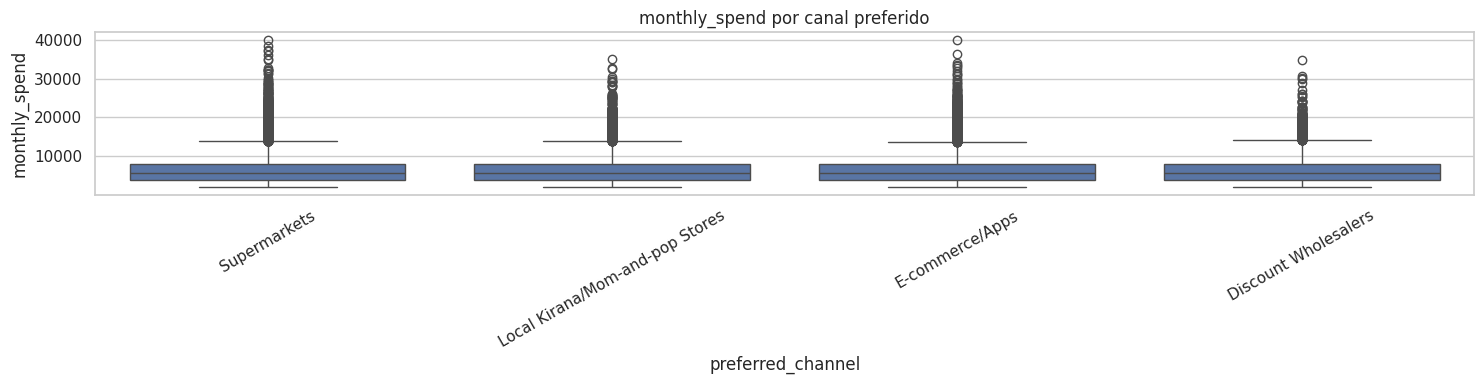

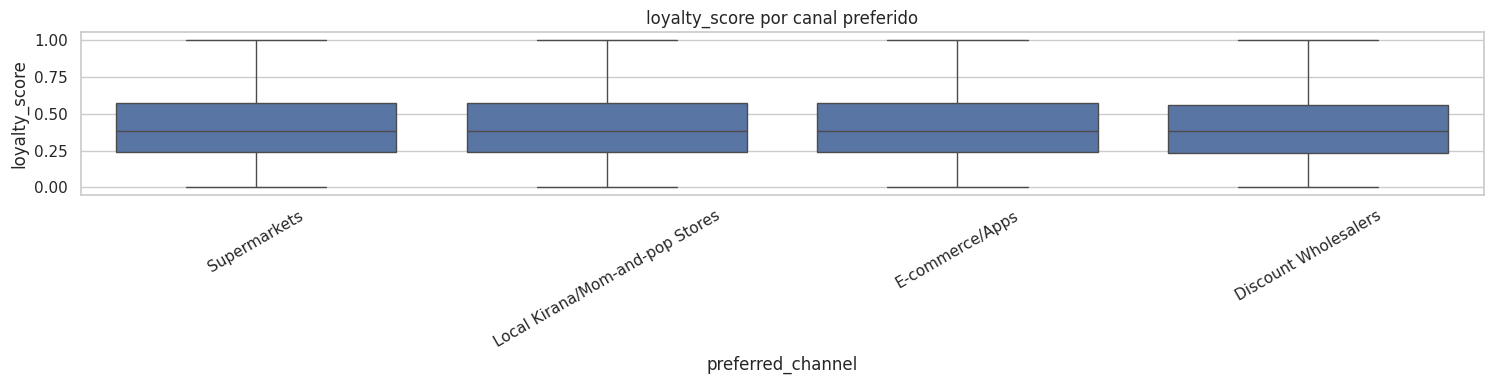

In [ ]:
# ============================================================
# 20) Variáveis numéricas x alvo
# Uso boxplots para ver diferenças de distribuição por canal.
# ============================================================

for col in ["age", "monthly_income", "monthly_spend", "loyalty_score"]:
    plt.figure(figsize=(15, 4))
    sns.boxplot(data=df, x=TARGET_COL, y=col)
    plt.title(f"{col} por canal preferido")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

### Comentário sobre os cruzamentos numéricos

Esses gráficos ajudam a verificar se certos canais parecem mais comuns em perfis com:
- maior renda;
- maior gasto;
- maior fidelidade;
- idade diferente.

Mesmo sem modelar ainda, isso já ajuda a formar uma intuição de negócio sobre a recomendação de anúncios.

## 9. Pré-processamento dos dados

Aqui começa uma das partes mais importantes do projeto.

O objetivo do pré-processamento é preparar os dados para que os modelos consigam aprender padrões de forma eficiente.

Sem essa etapa:
- o modelo pode aprender padrões errados,
- pode dar muito peso para variáveis em escala maior,
- ou simplesmente não conseguir interpretar variáveis categóricas.

Ou seja: **bons dados são mais importantes que modelos complexos.**


Agora começa a etapa de preparação da base.

Como o objetivo do MVP é chegar até essa etapa, vou:
- remover duplicatas;
- tratar missing, se existirem;
- separar target e features;
- aplicar encoding;
- gerar versões padronizadas e normalizadas;
- criar discretizações didáticas em algumas variáveis.

In [ ]:
# ============================================================
# 21) Criar cópia de trabalho
# Prefiro sempre separar a base original da base preparada.
# ============================================================

df_prep = df.copy()
print("Shape antes do pré-processamento:", df_prep.shape)

Shape antes do pré-processamento: (100000, 10)


In [ ]:
# ============================================================
# 22) Remover duplicatas
# Se houver duplicatas exatas, removo e registro o efeito.
# ============================================================

before = len(df_prep)
df_prep = df_prep.drop_duplicates().copy()
after = len(df_prep)

print("Linhas antes:", before)
print("Linhas depois:", after)
print("Duplicatas removidas:", before - after)

Linhas antes: 100000
Linhas depois: 99999
Duplicatas removidas: 1


In [ ]:
# ============================================================
# 23) Tratar missing values por tipo
# Mesmo que a base esteja quase limpa, a checagem formal é importante.
# ============================================================

df_clean = df_prep.copy()

numeric_cols_prep = df_clean.select_dtypes(include=["number"]).columns.tolist()
categorical_cols_prep = [col for col in df_clean.columns if col not in numeric_cols_prep]

if len(numeric_cols_prep) > 0:
    num_imputer = SimpleImputer(strategy="median")
    df_clean[numeric_cols_prep] = num_imputer.fit_transform(df_clean[numeric_cols_prep])

if len(categorical_cols_prep) > 0:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    df_clean[categorical_cols_prep] = cat_imputer.fit_transform(df_clean[categorical_cols_prep])

print("Missing depois do tratamento:")
display(df_clean.isna().sum().sort_values(ascending=False))

Missing depois do tratamento:


,0
age,0
household_size,0
monthly_income,0
monthly_spend,0
preferred_channel,0
brand_importance,0
price_importance,0
price_hike_reaction,0
primary_influence,0
loyalty_score,0


### Justificativa do tratamento de missing

Aqui eu mantive a regra geral:
- mediana para numéricas;
- moda para categóricas.

Nesta base, esse passo provavelmente terá pouco impacto prático, porque os dados parecem bem completos.  
Mas metodologicamente é importante mostrar que o diagnóstico foi feito.

In [ ]:
# ============================================================
# 24) Separar features e target
# Aqui faço a divisão mais importante para uma modelagem futura.
# ============================================================

X = df_clean.drop(columns=[TARGET_COL]).copy()
y = df_clean[TARGET_COL].copy()

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

display(X.head())
display(y.head())

Shape de X: (99999, 9)
Shape de y: (99999,)


,age,household_size,monthly_income,monthly_spend,brand_importance,price_importance,price_hike_reaction,primary_influence,loyalty_score
0,56.0,3.0,52500.0,9497.0,3.0,2.0,Continue buying the same brand,Social Media Ads,0.58
1,69.0,4.0,50500.0,7751.0,2.0,4.0,Switch to a cheaper brand,Social Media Ads,0.40
2,46.0,2.0,30500.0,3602.0,3.0,4.0,Switch to a cheaper brand,TV Commercials,0.45
3,32.0,2.0,51500.0,7967.0,2.0,4.0,Switch to a cheaper brand,In-store Displays,0.35
4,60.0,3.0,24000.0,4533.0,1.0,5.0,Switch to a cheaper brand,Doctor Recommendation,0.13


,preferred_channel
0,Supermarkets
1,Local Kirana/Mom-and-pop Stores
2,E-commerce/Apps
3,Supermarkets
4,E-commerce/Apps


In [ ]:
# ============================================================
# 25) Label encoding do target
# Como o alvo é categórico multiclasse, preciso codificá-lo.
# ============================================================

label_encoder = LabelEncoder()
y_encoded = pd.Series(label_encoder.fit_transform(y), name=f"{TARGET_COL}_encoded")

target_mapping = pd.DataFrame({
    "classe_original": label_encoder.classes_,
    "classe_codificada": range(len(label_encoder.classes_))
})

display(target_mapping)
display(y_encoded.head())

,classe_original,classe_codificada
0,Discount Wholesalers,0
1,E-commerce/Apps,1
2,Local Kirana/Mom-and-pop Stores,2
3,Supermarkets,3


,preferred_channel_encoded
0,3
1,2
2,1
3,3
4,1


### Justificativa da codificação do alvo

O alvo precisa ser transformado em números para etapas futuras de modelagem.

Faço isso com `LabelEncoder` porque:
- a coluna alvo é categórica;
- o problema é multiclasse;
- a codificação precisa ser simples e reproduzível.

In [ ]:
# ============================================================
# 26) One-hot encoding das features categóricas
# Essa é a transformação mais importante do lado das features.
# ============================================================

categorical_feature_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

X_onehot = pd.get_dummies(
    X,
    columns=categorical_feature_cols,
    drop_first=False
)

print("Shape após one-hot encoding:", X_onehot.shape)
display(X_onehot.head())

Shape após one-hot encoding: (99999, 15)


,age,household_size,monthly_income,monthly_spend,brand_importance,price_importance,loyalty_score,price_hike_reaction_Continue buying the same brand,price_hike_reaction_Look for discounts/offers,price_hike_reaction_Switch to a cheaper brand,primary_influence_Doctor Recommendation,primary_influence_In-store Displays,primary_influence_Social Media Ads,primary_influence_TV Commercials,primary_influence_Word of Mouth
0,56.0,3.0,52500.0,9497.0,3.0,2.0,0.58,True,False,False,False,False,True,False,False
1,69.0,4.0,50500.0,7751.0,2.0,4.0,0.40,False,False,True,False,False,True,False,False
2,46.0,2.0,30500.0,3602.0,3.0,4.0,0.45,False,False,True,False,False,False,True,False
3,32.0,2.0,51500.0,7967.0,2.0,4.0,0.35,False,False,True,False,True,False,False,False
4,60.0,3.0,24000.0,4533.0,1.0,5.0,0.13,False,False,True,True,False,False,False,False


In [ ]:
# ============================================================
# 27) Base final com target codificado
# Aqui junto as features tratadas com o alvo já codificado.
# ============================================================

df_model = X_onehot.copy()
df_model[f"{TARGET_COL}_encoded"] = y_encoded

display(df_model.head())
print("Shape da base de modelagem:", df_model.shape)

,age,household_size,monthly_income,monthly_spend,brand_importance,price_importance,loyalty_score,price_hike_reaction_Continue buying the same brand,price_hike_reaction_Look for discounts/offers,price_hike_reaction_Switch to a cheaper brand,primary_influence_Doctor Recommendation,primary_influence_In-store Displays,primary_influence_Social Media Ads,primary_influence_TV Commercials,primary_influence_Word of Mouth,preferred_channel_encoded
0,56.0,3.0,52500.0,9497.0,3.0,2.0,0.58,True,False,False,False,False,True,False,False,3.0
1,69.0,4.0,50500.0,7751.0,2.0,4.0,0.40,False,False,True,False,False,True,False,False,2.0
2,46.0,2.0,30500.0,3602.0,3.0,4.0,0.45,False,False,True,False,False,False,True,False,1.0
3,32.0,2.0,51500.0,7967.0,2.0,4.0,0.35,False,False,True,False,True,False,False,False,3.0
4,60.0,3.0,24000.0,4533.0,1.0,5.0,0.13,False,False,True,True,False,False,False,False,1.0


Shape da base de modelagem: (99999, 16)


In [ ]:
# ============================================================
# 28) Padronização das variáveis numéricas
# Faço em uma cópia separada para preservar versões diferentes.
# ============================================================

X_standardized = X_onehot.copy()

numeric_cols_model = X_standardized.select_dtypes(include=["number"]).columns.tolist()

if len(numeric_cols_model) > 0:
    scaler_std = StandardScaler()
    X_standardized[numeric_cols_model] = scaler_std.fit_transform(X_standardized[numeric_cols_model])

df_standardized = X_standardized.copy()
df_standardized[f"{TARGET_COL}_encoded"] = y_encoded

display(df_standardized.head())
print("Shape da base padronizada:", df_standardized.shape)

,age,household_size,monthly_income,monthly_spend,brand_importance,price_importance,loyalty_score,price_hike_reaction_Continue buying the same brand,price_hike_reaction_Look for discounts/offers,price_hike_reaction_Switch to a cheaper brand,primary_influence_Doctor Recommendation,primary_influence_In-store Displays,primary_influence_Social Media Ads,primary_influence_TV Commercials,primary_influence_Word of Mouth,preferred_channel_encoded
0,0.606450,-0.072187,0.527218,0.912324,0.433975,-1.505540,0.775130,True,False,False,False,False,True,False,False,3.0
1,1.397496,0.696897,0.436008,0.398316,-0.484112,0.231437,-0.023974,False,False,True,False,False,True,False,False,2.0
2,-0.002046,-0.841270,-0.476085,-0.823117,0.433975,0.231437,0.197999,False,False,True,False,False,False,True,False,1.0
3,-0.853942,-0.841270,0.481613,0.461904,-0.484112,0.231437,-0.245948,False,False,True,False,True,False,False,False,3.0
4,0.849849,-0.072187,-0.772516,-0.549038,-1.402199,1.099926,-1.222631,False,False,True,True,False,False,False,False,1.0


Shape da base padronizada: (99999, 16)


In [ ]:
# ============================================================
# 29) Normalização Min-Max
# Essa é outra visão útil do dataset para modelagem futura.
# ============================================================

X_normalized = X_onehot.copy()

numeric_cols_model = X_normalized.select_dtypes(include=["number"]).columns.tolist()

if len(numeric_cols_model) > 0:
    scaler_mm = MinMaxScaler()
    X_normalized[numeric_cols_model] = scaler_mm.fit_transform(X_normalized[numeric_cols_model])

df_normalized = X_normalized.copy()
df_normalized[f"{TARGET_COL}_encoded"] = y_encoded

display(df_normalized.head())
print("Shape da base normalizada:", df_normalized.shape)

,age,household_size,monthly_income,monthly_spend,brand_importance,price_importance,loyalty_score,price_hike_reaction_Continue buying the same brand,price_hike_reaction_Look for discounts/offers,price_hike_reaction_Switch to a cheaper brand,primary_influence_Doctor Recommendation,primary_influence_In-store Displays,primary_influence_Social Media Ads,primary_influence_TV Commercials,primary_influence_Word of Mouth,preferred_channel_encoded
0,0.678571,0.4,0.139403,0.197289,0.50,0.25,0.58,True,False,False,False,False,True,False,False,3.0
1,0.910714,0.6,0.133713,0.151342,0.25,0.75,0.40,False,False,True,False,False,True,False,False,2.0
2,0.500000,0.2,0.076814,0.042158,0.50,0.75,0.45,False,False,True,False,False,False,True,False,1.0
3,0.250000,0.2,0.136558,0.157026,0.25,0.75,0.35,False,False,True,False,True,False,False,False,3.0
4,0.750000,0.4,0.058321,0.066658,0.00,1.00,0.13,False,False,True,True,False,False,False,False,1.0


Shape da base normalizada: (99999, 16)


In [ ]:
# ============================================================
# 30) Discretização didática de variáveis selecionadas
# Aqui crio faixas para idade, renda e gasto.
# Isso ajuda muito na explicação em aula.
# ============================================================

df_binned = df_clean.copy()

for col in ["age", "monthly_income", "monthly_spend"]:
    if col in df_binned.columns:
        try:
            df_binned[f"{col}_faixa"] = pd.qcut(df_binned[col], q=4, duplicates="drop")
        except Exception:
            pass

display(df_binned.head())

,age,household_size,monthly_income,monthly_spend,preferred_channel,brand_importance,price_importance,price_hike_reaction,primary_influence,loyalty_score,age_faixa,monthly_income_faixa,monthly_spend_faixa
0,56.0,3.0,52500.0,9497.0,Supermarkets,3.0,2.0,Continue buying the same brand,Social Media Ads,0.58,"(46.0, 60.0]","(50500.0, 355000.0]","(7986.0, 40000.0]"
1,69.0,4.0,50500.0,7751.0,Local Kirana/Mom-and-pop Stores,2.0,4.0,Switch to a cheaper brand,Social Media Ads,0.40,"(60.0, 74.0]","(36000.0, 50500.0]","(5733.0, 7986.0]"
2,46.0,2.0,30500.0,3602.0,E-commerce/Apps,3.0,4.0,Switch to a cheaper brand,TV Commercials,0.45,"(32.0, 46.0]","(25500.0, 36000.0]","(1999.999, 4019.0]"
3,32.0,2.0,51500.0,7967.0,Supermarkets,2.0,4.0,Switch to a cheaper brand,In-store Displays,0.35,"(17.999, 32.0]","(50500.0, 355000.0]","(5733.0, 7986.0]"
4,60.0,3.0,24000.0,4533.0,E-commerce/Apps,1.0,5.0,Switch to a cheaper brand,Doctor Recommendation,0.13,"(46.0, 60.0]","(3499.999, 25500.0]","(4019.0, 5733.0]"


### Justificativa da discretização

A discretização é útil em aula porque ajuda a transformar números contínuos em faixas interpretáveis.

Por exemplo:
- idade em grupos;
- renda em faixas;
- gasto mensal em níveis.

Isso não substitui a versão contínua, mas cria uma visão complementar muito boa para interpretação.

In [ ]:
# ============================================================
# 31) Salvar os arquivos gerados
# Aqui deixo as principais visões do dataset prontas.
# ============================================================

clean_path = PROJECT_DIR / "ads_clean.csv"
onehot_path = PROJECT_DIR / "ads_onehot.csv"
standardized_path = PROJECT_DIR / "ads_standardized.csv"
normalized_path = PROJECT_DIR / "ads_normalized.csv"
binned_path = PROJECT_DIR / "ads_binned.csv"
target_map_path = PROJECT_DIR / "target_mapping.csv"

df_clean.to_csv(clean_path, index=False)
df_model.to_csv(onehot_path, index=False)
df_standardized.to_csv(standardized_path, index=False)
df_normalized.to_csv(normalized_path, index=False)
df_binned.to_csv(binned_path, index=False)
target_mapping.to_csv(target_map_path, index=False)

print("Arquivos salvos com sucesso.")

Arquivos salvos com sucesso.


In [ ]:
# ============================================================
# 32) Comparar shapes das bases geradas
# Isso ajuda a visualizar o efeito do pré-processamento.
# ============================================================

comparison_shapes = pd.DataFrame({
    "base": [
        "df_clean",
        "df_model_onehot",
        "df_standardized",
        "df_normalized",
        "df_binned"
    ],
    "linhas": [
        df_clean.shape[0],
        df_model.shape[0],
        df_standardized.shape[0],
        df_normalized.shape[0],
        df_binned.shape[0]
    ],
    "colunas": [
        df_clean.shape[1],
        df_model.shape[1],
        df_standardized.shape[1],
        df_normalized.shape[1],
        df_binned.shape[1]
    ]
})

display(comparison_shapes)

,base,linhas,colunas
0,df_clean,99999,10
1,df_model_onehot,99999,16
2,df_standardized,99999,16
3,df_normalized,99999,16
4,df_binned,99999,13


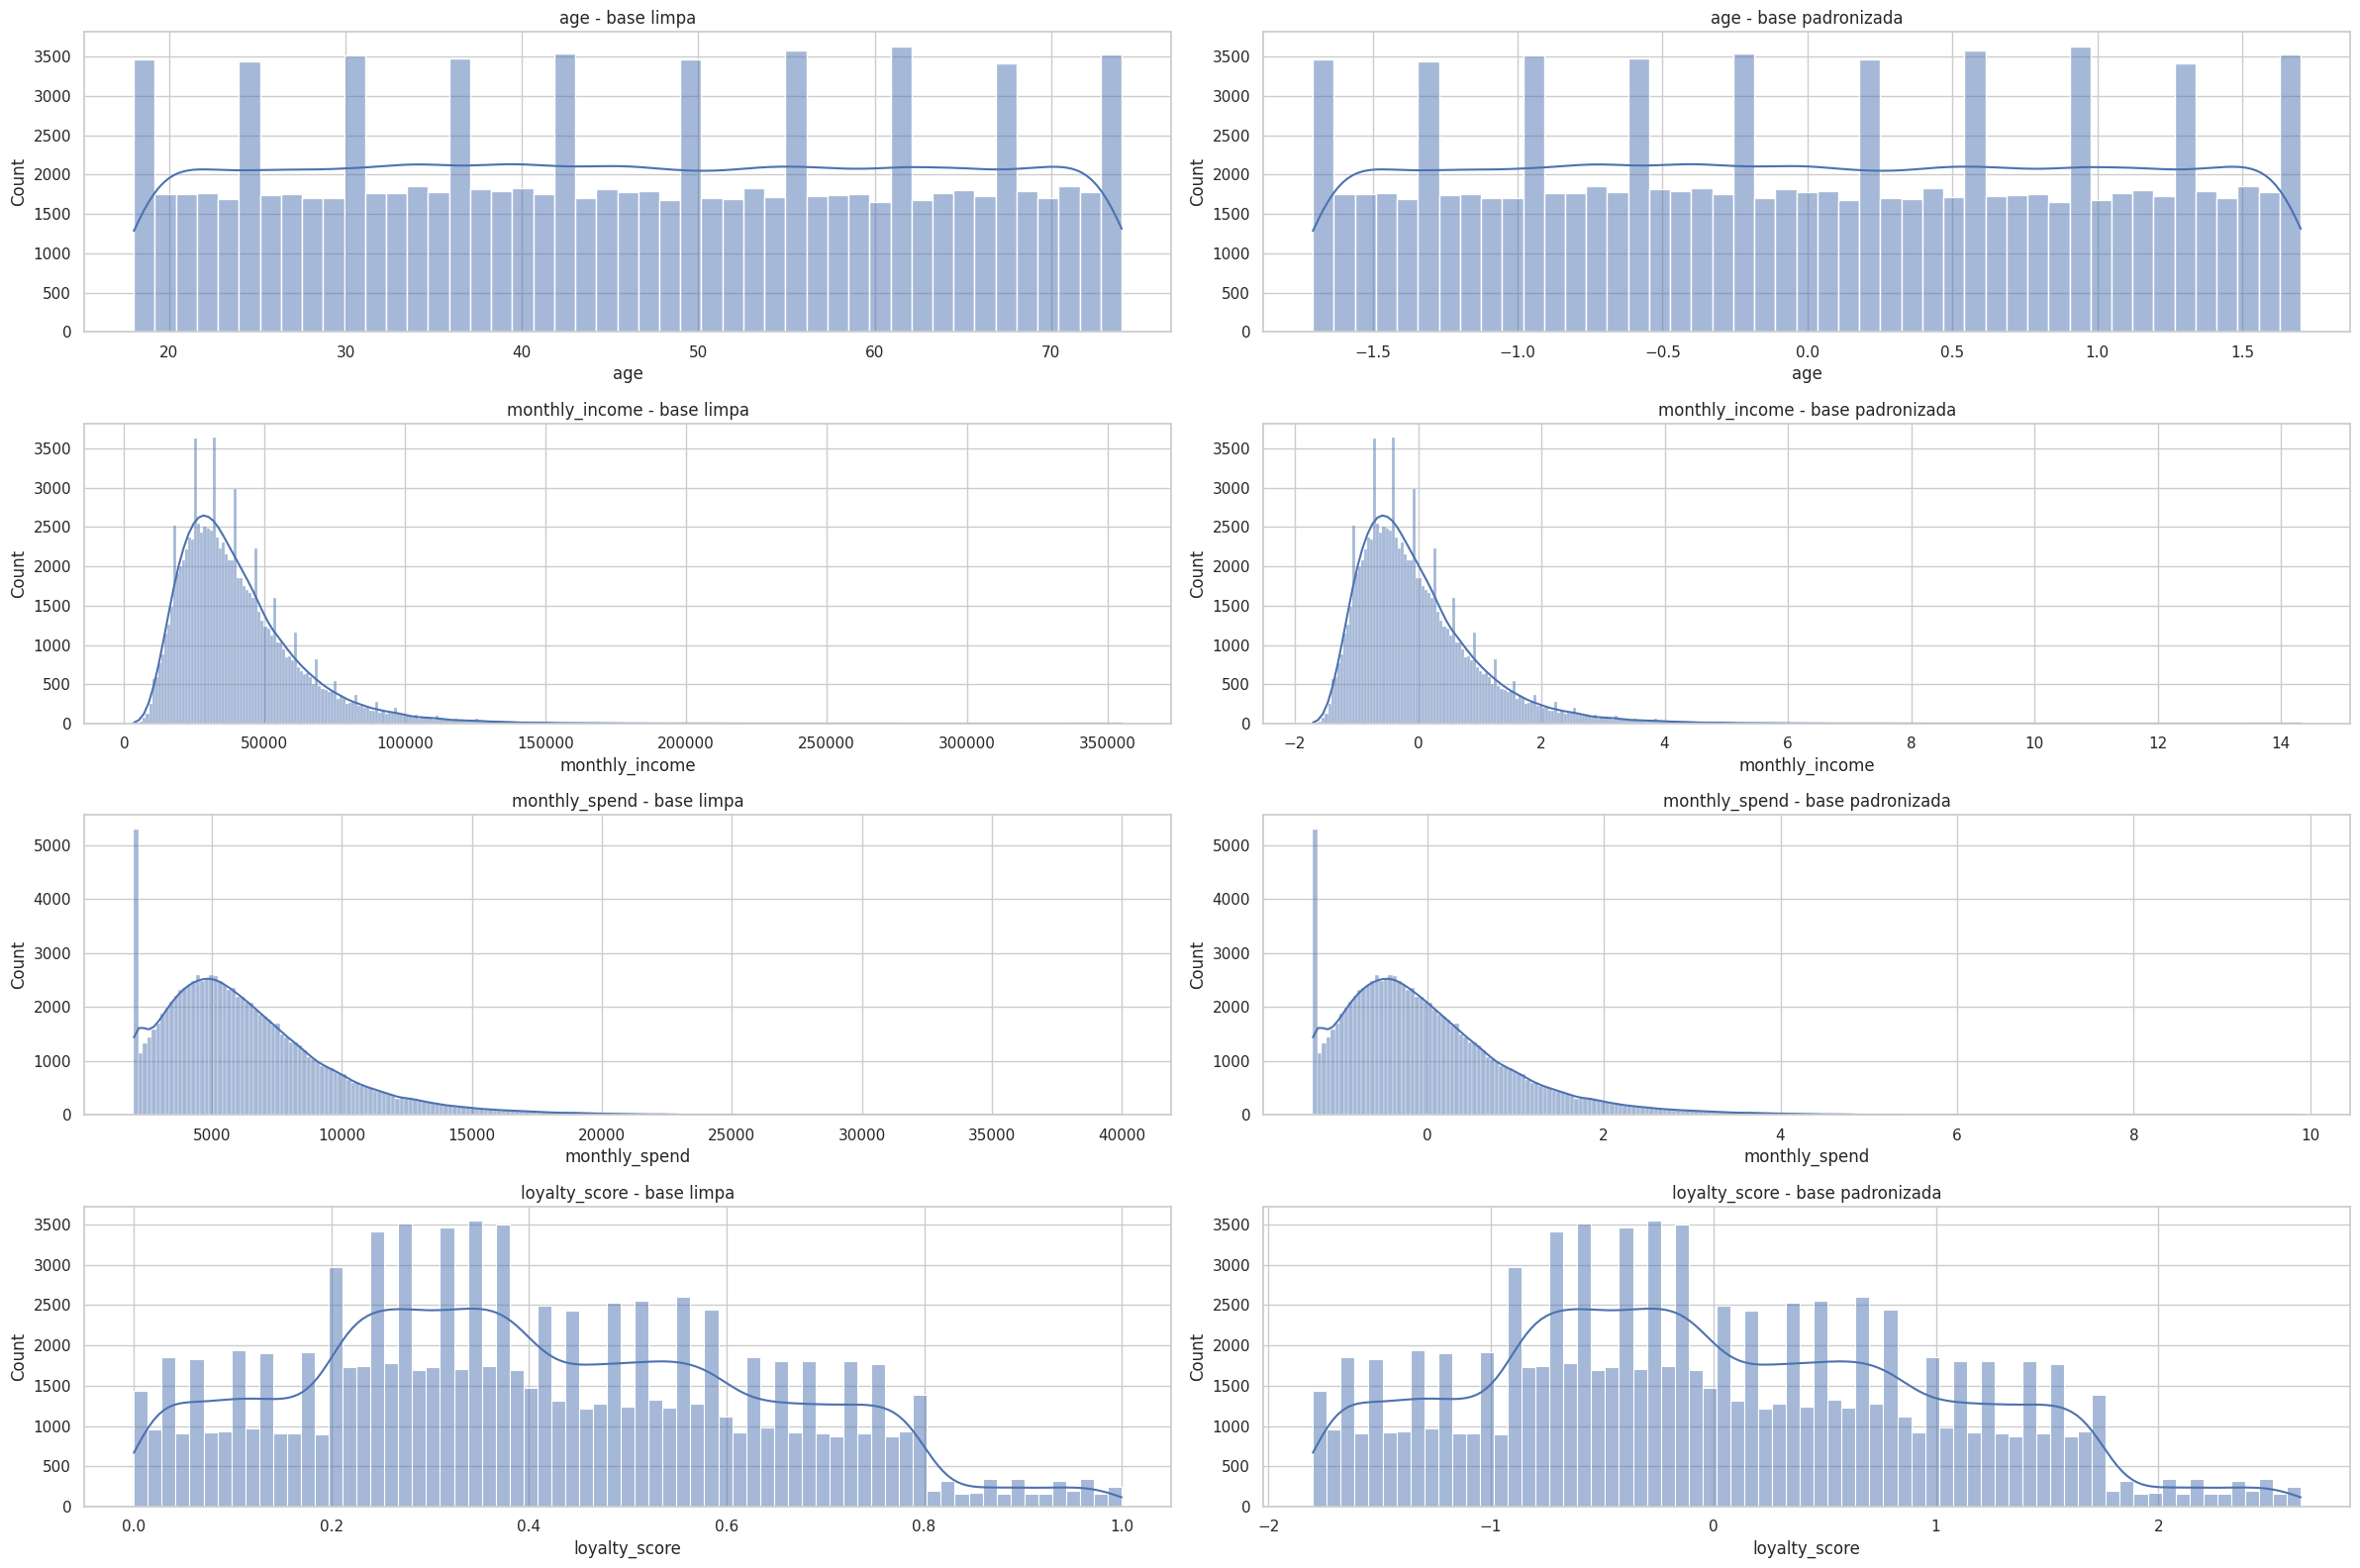

In [ ]:
# ============================================================
# 33) Reanálise rápida de uma transformação
# Aqui comparo a distribuição antes e depois da padronização.
# ============================================================

compare_cols = ["age", "monthly_income", "monthly_spend", "loyalty_score"]

fig, axes = plt.subplots(len(compare_cols), 2, figsize=(24, 4 * len(compare_cols)))

for i, col in enumerate(compare_cols):
    sns.histplot(df_clean[col], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f"{col} - base limpa")

    if col in df_standardized.columns:
        sns.histplot(df_standardized[col], kde=True, ax=axes[i, 1])
        axes[i, 1].set_title(f"{col} - base padronizada")

plt.tight_layout()
plt.show()

## 10. Modelagem e comparação de modelos

Agora entramos na etapa de machine learning.

Aqui o objetivo é responder a pergunta principal do projeto:

> “Qual modelo consegue prever melhor o canal preferido do usuário?”

A ideia NÃO é só treinar modelos, mas:
- comparar abordagens diferentes,
- entender como cada modelo funciona,
- interpretar os resultados.

Isso é o que diferencia um projeto técnico de um projeto bem explicado.


Até aqui, o projeto foi da leitura da base até o pré-processamento.  
Agora entra a etapa de modelagem propriamente dita.

Como o objetivo é prever o **canal preferido** do consumidor, o problema será tratado como **classificação multiclasse**.

Vou seguir uma sequência didática:
1. separar treino e teste;  
2. treinar modelos diferentes;  
3. gerar previsões;  
4. comparar métricas;  
5. interpretar resultados.

In [ ]:
# ============================================================
# 34) Imports da etapa de modelagem
# Aqui entram as ferramentas de split, treino e avaliação.
# ============================================================

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

### Decisão sobre a base de modelagem

Para a etapa de classificação, vou usar a base com:
- **features tratadas por one-hot encoding**;
- **target codificado numericamente**.

Essa é a base mais apropriada para treinar os classificadores neste projeto.

In [ ]:
# ============================================================
# 35) Definir X e y finais para modelagem
# Aqui uso a base com one-hot nas features e target codificado.
# ============================================================

X_model = X_onehot.copy()
y_model = y_encoded.copy()

print("Shape de X_model:", X_model.shape)
print("Shape de y_model:", y_model.shape)

display(X_model.head())
display(y_model.head())

Shape de X_model: (99999, 15)
Shape de y_model: (99999,)


,age,household_size,monthly_income,monthly_spend,brand_importance,price_importance,loyalty_score,price_hike_reaction_Continue buying the same brand,price_hike_reaction_Look for discounts/offers,price_hike_reaction_Switch to a cheaper brand,primary_influence_Doctor Recommendation,primary_influence_In-store Displays,primary_influence_Social Media Ads,primary_influence_TV Commercials,primary_influence_Word of Mouth
0,56.0,3.0,52500.0,9497.0,3.0,2.0,0.58,True,False,False,False,False,True,False,False
1,69.0,4.0,50500.0,7751.0,2.0,4.0,0.40,False,False,True,False,False,True,False,False
2,46.0,2.0,30500.0,3602.0,3.0,4.0,0.45,False,False,True,False,False,False,True,False
3,32.0,2.0,51500.0,7967.0,2.0,4.0,0.35,False,False,True,False,True,False,False,False
4,60.0,3.0,24000.0,4533.0,1.0,5.0,0.13,False,False,True,True,False,False,False,False


,preferred_channel_encoded
0,3
1,2
2,1
3,3
4,1


In [ ]:
# ============================================================
# 36) Separação treino e teste
# Uso stratify para preservar a proporção das classes.
# Isso é importante em classificação multiclasse.
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    random_state=42,
    stratify=y_model
)

print("Treino:", X_train.shape, y_train.shape)
print("Teste:", X_test.shape, y_test.shape)

Treino: (79999, 15) (79999,)
Teste: (20000, 15) (20000,)


### Justificativa da separação treino e teste

Essa separação é necessária para avaliar se o modelo generaliza bem.  
A ideia é simples:
- o modelo aprende no conjunto de treino;
- depois é testado em dados que ele não viu.

Uso `stratify=y_model` para manter a proporção das classes no treino e no teste.

In [ ]:
# ============================================================
# 37) Definir os modelos
# Escolhi três modelos bem didáticos e comuns:
# - Regressão Logística
# - KNN
# - Random Forest
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

list(models.keys())

['Logistic Regression', 'KNN', 'Random Forest']

### Por que esses modelos?

- **Logistic Regression**: é um modelo linear, simples e bom para servir de baseline;  
- **KNN**: ajuda a mostrar uma lógica baseada em proximidade entre observações;  
- **Random Forest**: é um modelo mais flexível, capaz de capturar relações não lineares.

Isso é ótimo para aula, porque permite comparar modelos com lógicas bem diferentes.

In [ ]:
# ============================================================
# 38) Função de avaliação
# Aqui concentro as métricas em um lugar só.
# ============================================================

def evaluate_classifier(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    metrics = {
        "train_accuracy": accuracy_score(y_train, y_pred_train),
        "test_accuracy": accuracy_score(y_test, y_pred_test),
        "precision_macro": precision_score(y_test, y_pred_test, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred_test, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred_test, average="macro", zero_division=0)
    }

    return {
        "model": model,
        "metrics": metrics,
        "y_pred_test": y_pred_test
    }

In [ ]:
# ============================================================
# 39) Treinar e avaliar os modelos
# Aqui executo todos e guardo os resultados.
# ============================================================

results = {}

for model_name, model in models.items():
    results[model_name] = evaluate_classifier(
        model=model,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test
    )

results.keys()

dict_keys(['Logistic Regression', 'KNN', 'Random Forest'])

In [ ]:
# ============================================================
# 40) Comparação consolidada dos modelos
# Essa tabela é uma das partes mais importantes do projeto.
# ============================================================

comparison_rows = []

for model_name, result in results.items():
    row = {"modelo": model_name}
    row.update(result["metrics"])
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    by=["test_accuracy", "f1_macro"],
    ascending=False
).reset_index(drop=True)

display(comparison_df)

,modelo,train_accuracy,test_accuracy,precision_macro,recall_macro,f1_macro
0,Logistic Regression,0.400130,0.40015,0.100038,0.250000,0.142895
1,Random Forest,0.999987,0.35075,0.250288,0.248248,0.226568
2,KNN,0.504519,0.31905,0.251031,0.249751,0.245981


### Como interpretar a tabela de comparação

As métricas principais aqui são:

- **Accuracy**: proporção total de acertos.
  → Intuição: “de tudo que o modelo previu, quantos ele acertou?”

- **Precision**: qualidade das previsões positivas.
  → Intuição: “quando o modelo diz que é X, ele acerta?”

- **Recall**: capacidade de encontrar os casos reais.
  → Intuição: “dos X de verdade, quantos ele encontrou?”

- **F1-score**: equilíbrio entre precision e recall.
  → Intuição: evita modelos que são bons em uma métrica mas ruins em outra.


- **test_accuracy**: proporção total de acertos no conjunto de teste;  
- **precision_macro**: média da precisão entre as classes;  
- **recall_macro**: média da sensibilidade entre as classes;  
- **f1_macro**: média harmônica entre precisão e recall.

Em problemas multiclasse, usar apenas accuracy pode esconder desempenho ruim em classes específicas.  
Por isso, também olho as métricas macro.

In [ ]:
# ============================================================
# 41) Classification report de cada modelo
# Aqui eu detalho o desempenho por classe.
# ============================================================

for model_name, result in results.items():
    print("=" * 80)
    print(f"Modelo: {model_name}")
    print(classification_report(y_test, result["y_pred_test"], zero_division=0))

Modelo: Logistic Regression
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1988
           1       0.00      0.00      0.00      6005
           2       0.00      0.00      0.00      4004
           3       0.40      1.00      0.57      8003

    accuracy                           0.40     20000
   macro avg       0.10      0.25      0.14     20000
weighted avg       0.16      0.40      0.23     20000

Modelo: KNN
              precision    recall  f1-score   support

           0       0.10      0.06      0.08      1988
           1       0.30      0.35      0.32      6005
           2       0.21      0.13      0.16      4004
           3       0.40      0.45      0.42      8003

    accuracy                           0.32     20000
   macro avg       0.25      0.25      0.25     20000
weighted avg       0.30      0.32      0.31     20000

Modelo: Random Forest
              precision    recall  f1-score   support

           0 

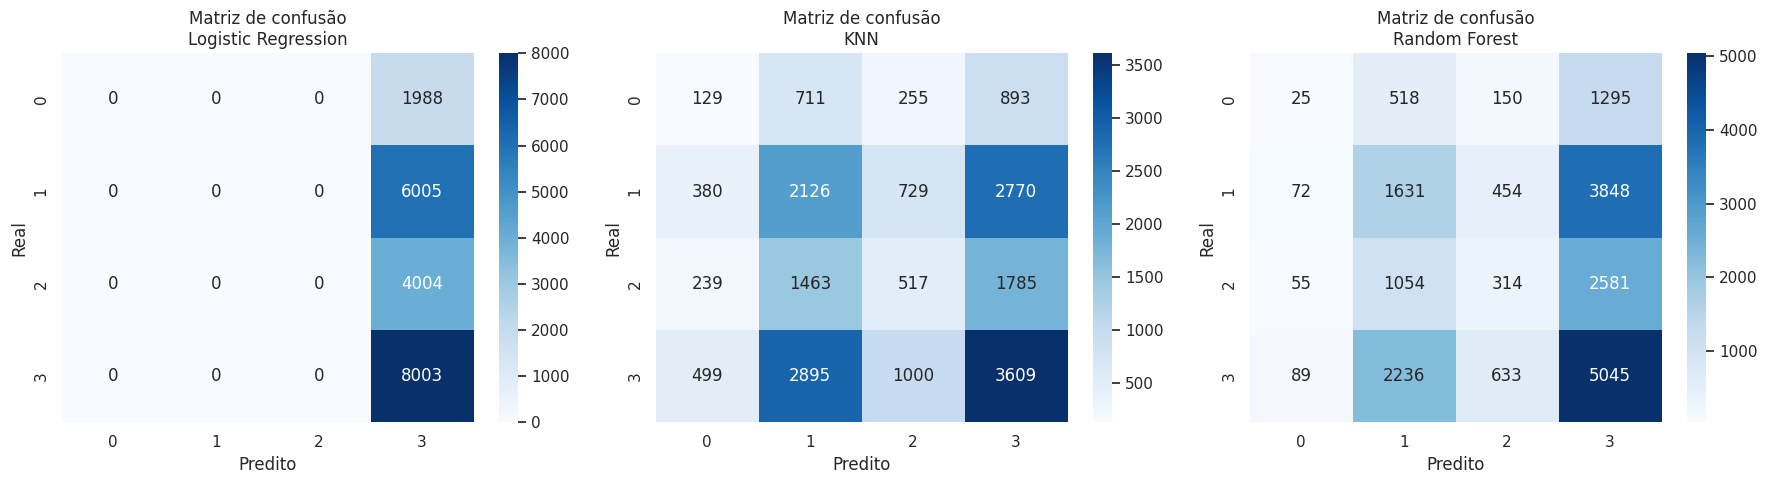

In [ ]:
# ============================================================
# 42) Matrizes de confusão
# Isso ajuda a enxergar quais classes estão sendo confundidas.
# ============================================================

n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))

if n_models == 1:
    axes = [axes]

for ax, (model_name, result) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, result["y_pred_test"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"Matriz de confusão\n{model_name}")
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()

### Comentário sobre as matrizes de confusão

A matriz de confusão ajuda a ver:
- quais classes o modelo acerta mais;
- quais classes ele confunde;
- se existe algum canal muito parecido com outro aos olhos do modelo.

Isso é muito útil para explicar resultados em aula, porque torna a avaliação mais visual.

In [ ]:
# ============================================================
# 43) Validação cruzada simples
# Aqui eu faço uma checagem complementar da estabilidade dos modelos.
# ============================================================

cv_rows = []

for model_name, model in models.items():
    scores = cross_val_score(model, X_model, y_model, cv=5, scoring="accuracy", n_jobs=None)
    cv_rows.append({
        "modelo": model_name,
        "cv_accuracy_mean": scores.mean(),
        "cv_accuracy_std": scores.std()
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values(
    by="cv_accuracy_mean",
    ascending=False
).reset_index(drop=True)

display(cv_results_df)

,modelo,cv_accuracy_mean,cv_accuracy_std
0,Logistic Regression,0.400134,0.000021
1,Random Forest,0.352784,0.001736
2,KNN,0.318423,0.002300


### Por que usar validação cruzada?

A validação cruzada ajuda a reduzir a dependência de uma única divisão treino/teste.  
Ela oferece uma visão complementar da estabilidade do modelo ao longo de diferentes partições dos dados.

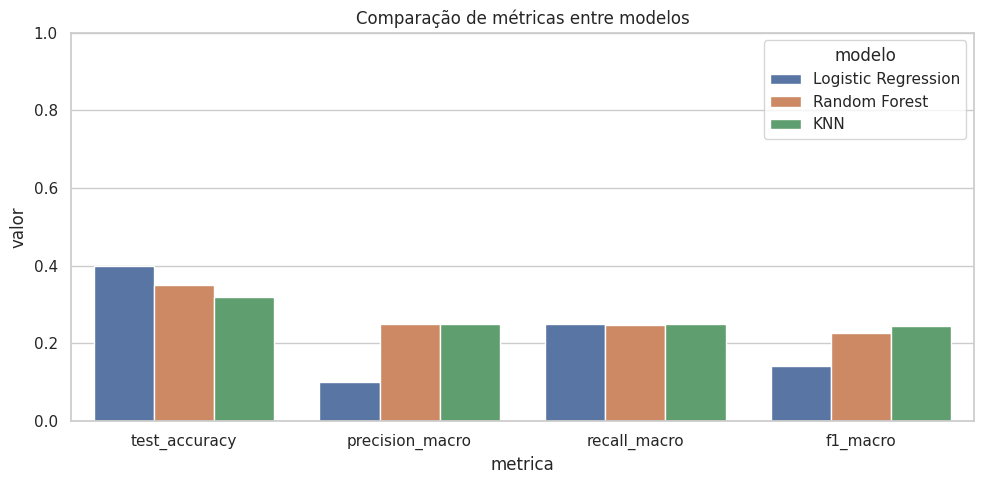

In [ ]:
# ============================================================
# 44) Comparação visual das métricas
# Aqui deixo a comparação mais didática.
# ============================================================

plot_df = comparison_df.melt(
    id_vars="modelo",
    value_vars=["test_accuracy", "precision_macro", "recall_macro", "f1_macro"],
    var_name="metrica",
    value_name="valor"
)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="metrica", y="valor", hue="modelo")
plt.title("Comparação de métricas entre modelos")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 45) Melhor modelo segundo test_accuracy
# Aqui escolho um critério objetivo para resumir o resultado.
# ============================================================

best_model_name = comparison_df.iloc[0]["modelo"]
best_model = results[best_model_name]["model"]

print("Melhor modelo segundo test_accuracy:", best_model_name)
print(comparison_df.iloc[0])

Melhor modelo segundo test_accuracy: Logistic Regression
modelo             Logistic Regression
train_accuracy                 0.40013
test_accuracy                  0.40015
precision_macro               0.100038
recall_macro                      0.25
f1_macro                      0.142895
Name: 0, dtype: object


### Escolha do melhor modelo

Aqui usei como critério principal a **accuracy no conjunto de teste**.  
Mas, em um projeto real, eu também consideraria:

- estabilidade na validação cruzada;  
- desempenho macro entre as classes;  
- interpretabilidade;  
- custo computacional.

Isso é importante de explicar em aula: o “melhor” modelo nem sempre é apenas o que tem a maior accuracy.

,feature,importance
3,monthly_spend,0.243567
2,monthly_income,0.213803
0,age,0.200617
6,loyalty_score,0.190339
1,household_size,0.073627
4,brand_importance,0.019958
5,price_importance,0.015690
10,primary_influence_Doctor Recommendation,0.007388
14,primary_influence_Word of Mouth,0.007350
13,primary_influence_TV Commercials,0.007142


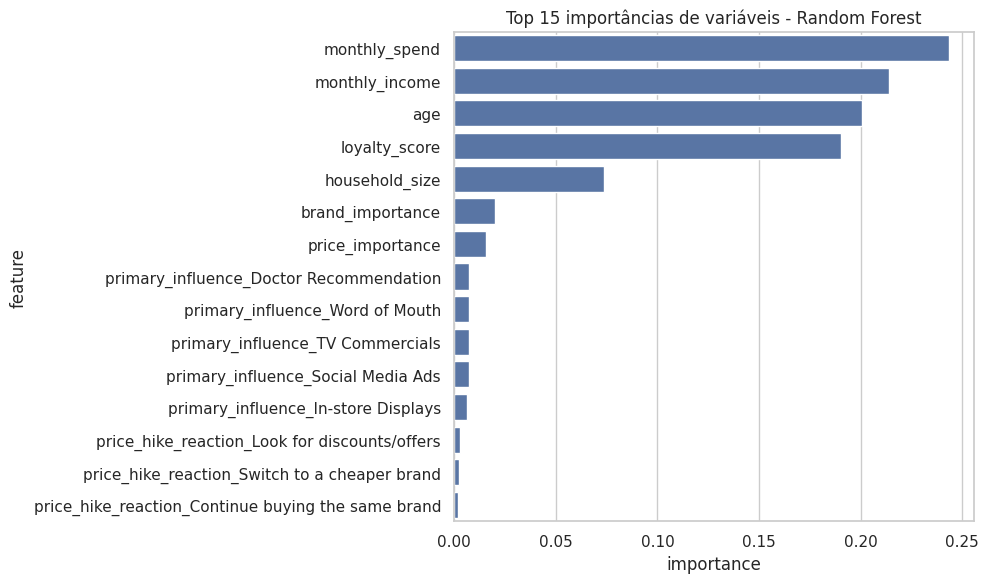

In [ ]:
# ============================================================
# 46) Importância das variáveis no Random Forest
# Mesmo que ele não seja o melhor, essa parte é muito útil didaticamente.
# ============================================================

rf_model = results["Random Forest"]["model"]

feature_importance = pd.DataFrame({
    "feature": X_model.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False).head(15)

display(feature_importance)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x="importance", y="feature")
plt.title("Top 15 importâncias de variáveis - Random Forest")
plt.tight_layout()
plt.show()

### Comentário sobre importância das variáveis

Esse gráfico ajuda a responder uma pergunta muito valiosa:

> quais atributos mais ajudam a prever o canal preferido?

Isso aproxima o projeto de uma análise de negócio, porque permite discutir quais fatores parecem mais relevantes para direcionamento de anúncios.

## 11. Conclusões

Este notebook agora cumpre o ciclo completo do projeto, indo:
- da leitura da base;
- passando por análise exploratória;
- pré-processamento;
- modelagem;
- comparação de modelos;
- interpretação dos resultados.

### O que foi definido
- o problema foi formulado como **classificação multiclasse**;
- a variável alvo escolhida foi **`preferred_channel`**;
- a coluna `user_id` foi removida por ser apenas identificador.

### O que foi analisado
- estrutura da base;
- tipos das variáveis;
- valores faltantes;
- duplicatas;
- estatísticas descritivas;
- distribuições dos atributos;
- relações entre atributos e o canal preferido.

### O que foi preparado
- base limpa;
- target codificado;
- features com one-hot encoding;
- base padronizada;
- base normalizada;
- base com discretização.

### O que foi modelado
- **Logistic Regression**;
- **KNN**;
- **Random Forest**.

### O que foi comparado
- accuracy em treino e teste;
- precision, recall e F1 macro;
- classification report;
- matriz de confusão;
- validação cruzada.

### Próximos passos
Uma continuação natural deste projeto seria:
1. ajustar hiperparâmetros dos modelos;  
2. testar outros algoritmos;  
3. usar estratégias mais próximas de ranking/recomendação;  
4. fazer segmentação de usuários;  
5. transformar os resultados em uma política prática de recomendação de anúncios.

## 12. Sugestão de sequência para explicar em aula

Uma sequência didática boa para apresentar este notebook é:

1. apresentar o problema de negócio: escolher o melhor canal para o anúncio;  
2. mostrar o dataset e explicar cada coluna;  
3. justificar a escolha de `preferred_channel` como alvo;  
4. mostrar missing e duplicatas;  
5. interpretar os gráficos mais importantes;  
6. explicar por que `user_id` sai da modelagem;  
7. mostrar encoding, padronização, normalização e discretização;  
8. explicar treino/teste;  
9. comparar os três modelos;  
10. discutir a matriz de confusão e as importâncias do Random Forest;  
11. encerrar com a escolha do melhor modelo e próximos passos.

Assim, a aluna consegue entender não apenas o código, mas também a lógica do projeto completo.

## 10. Conclusões

Este notebook cumpriu a proposta do MVP até a etapa de pré-processamento, agora de forma muito mais aderente ao problema real da base.

### O que foi definido
- o problema foi formulado como **classificação multiclasse**;
- a variável alvo escolhida foi **`preferred_channel`**;
- a coluna `user_id` foi removida por ser apenas identificador.

### O que foi analisado
- estrutura da base;
- tipos das variáveis;
- valores faltantes;
- duplicatas;
- estatísticas descritivas;
- distribuições dos atributos;
- relações entre atributos e o canal preferido.

### O que foi preparado
- base limpa;
- target codificado;
- features com one-hot encoding;
- base padronizada;
- base normalizada;
- base com discretização.

### Próximos passos
Uma continuação natural deste projeto seria:
1. dividir treino e teste;
2. treinar um classificador inicial;
3. comparar modelos;
4. interpretar quais atributos mais ajudam a prever o canal preferido;
5. usar isso como base para uma política de recomendação de anúncios.

## 11. Sugestão de sequência para explicar em aula

Uma sequência didática boa para apresentar este notebook é:

1. apresentar o problema de negócio: escolher o melhor canal para o anúncio;  
2. mostrar o dataset e explicar cada coluna;  
3. justificar a escolha de `preferred_channel` como alvo;  
4. mostrar missing e duplicatas;  
5. interpretar os gráficos mais importantes;  
6. explicar por que `user_id` sai da modelagem;  
7. mostrar encoding, padronização, normalização e discretização;  
8. encerrar explicando como isso prepara a base para um futuro modelo.

Assim, a aluna consegue entender não apenas o código, mas também a lógica de análise por trás dele.

In [ ]:
# ============================================================
# 34) Listar arquivos gerados
# Isso ajuda a conferir o que saiu do projeto.
# ============================================================

generated_files = sorted([p.name for p in PROJECT_DIR.glob("*")])

print("Arquivos gerados:")
for f in generated_files:
    print("-", f)

Arquivos gerados:
- ads_binned.csv
- ads_clean.csv
- ads_normalized.csv
- ads_onehot.csv
- ads_standardized.csv
- target_mapping.csv
